In [ ]:
import re
import matplotlib.pyplot as plt

def parse_and_plot_qemu_log(filename):
    import matplotlib.pyplot as plt

    # 初始化字典，用于存储不同 eid 的数据
    data_by_eid = {}

    schedule_sequence = []

    # 正则表达式提取变量
    pattern = re.compile(
        r"eid:\s*(\d+),\s*current_ptime:\s*(\d+),\s*etime:\s*(\d+),\s*ptime:\s*(\d+),\s*ptime_interrupt:\s*(\d+),\s*time_debt:\s*(-?\d+)d"
    )

    with open(filename, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                eid = int(match.group(1))
                current_ptime = int(match.group(2))
                etime = int(match.group(3))
                ptime = int(match.group(4))
                ptime_interrupt = int(match.group(5))
                time_debt = int(match.group(6))

                # # 如果ptime>4e8,停止绘图
                # if current_ptime > 4e8:
                #     print(f"Stopping plot for eid {eid} at current_ptime {current_ptime} due to ptime > 4e8")
                #     break

                schedule_sequence.append({'time': current_ptime, 'eid': eid})
                
                # 如果 eid 不在字典中，初始化数据结构
                if eid not in data_by_eid:
                    data_by_eid[eid] = {
                        "current_ptime": [],
                        "etime": [],
                        "ptime": [],
                        "ptime_interrupt": [],
                        "time_debt": []
                    }
                
                # 添加数据到对应 eid 的列表中
                data_by_eid[eid]["current_ptime"].append(current_ptime)
                data_by_eid[eid]["etime"].append(etime)
                data_by_eid[eid]["ptime"].append(ptime)
                data_by_eid[eid]["ptime_interrupt"].append(ptime_interrupt)
                data_by_eid[eid]["time_debt"].append(time_debt)

    # 绘图
    fig, axs = plt.subplots(5, 1, figsize=(10, 22), sharex=True)

    # 绘制 ptime_interrupt
    for eid, data in data_by_eid.items():
        axs[0].plot(data["current_ptime"], data["ptime_interrupt"], label=f'eid {eid}')
    axs[0].set_ylabel('ptime_interrupt')
    axs[0].legend()
    axs[0].autoscale()

    # 绘制 y=x 基准线
    min_val = min(min(data["current_ptime"]) for data in data_by_eid.values())
    max_val = max(max(data["current_ptime"]) for data in data_by_eid.values())
    axs[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')
    axs[0].legend()

    # 绘制 time_debt
    for eid, data in data_by_eid.items():
        axs[1].plot(data["current_ptime"], data["time_debt"], label=f'eid {eid}')
    axs[1].set_ylabel('time_debt')
    axs[1].legend()
    axs[1].autoscale()

    # 绘制 etime
    for eid, data in data_by_eid.items():
        axs[2].plot(data["current_ptime"], data["etime"], label=f'eid {eid}')
    axs[2].set_ylabel('etime')
    axs[2].legend()
    axs[2].autoscale()

    # 绘制 ptime
    for eid, data in data_by_eid.items():
        axs[3].plot(data["current_ptime"], data["ptime"], label=f'eid {eid}')
    axs[3].set_ylabel('ptime')
    axs[3].set_xlabel('current_ptime')
    axs[3].legend()
    axs[3].autoscale()

    # 绘制调度情况 (Gantt-like chart)
    if schedule_sequence:
        unique_eids = sorted(list(data_by_eid.keys()))
        
        # 为每个 eid 分配一个固定颜色
        colors = plt.cm.get_cmap('tab10', len(unique_eids))
        eid_to_color = {eid: colors(i) for i, eid in enumerate(unique_eids)}

        for i in range(len(schedule_sequence) - 1):
            start_event = schedule_sequence[i]
            end_event = schedule_sequence[i+1]
            
            eid = start_event['eid']
            start_time = start_event['time']
            duration = end_event['time'] - start_time
            
            if duration > 0:
                # 在同一条时间轴 (y=0) 上绘制，并使用固定颜色
                axs[4].barh(y=0, width=duration, left=start_time, height=0.6, align='center', color=eid_to_color[eid])
        
        # 处理最后一个事件
        if len(schedule_sequence) > 0:
            last_event = schedule_sequence[-1]
            max_time = max(max(data["current_ptime"]) for data in data_by_eid.values())
            duration = max_time - last_event['time']
            if duration > 0:
                 axs[4].barh(y=0, width=duration, left=last_event['time'], height=0.6, align='center', color=eid_to_color[last_event['eid']])

        # 创建图例来显示颜色和 eid 的对应关系
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=eid_to_color[eid], label=f'eid {eid}') for eid in unique_eids]
        axs[4].legend(handles=legend_elements)

        # 移除 Y 轴刻度和标签
        axs[4].set_yticks([])
        axs[4].set_ylabel('Schedule')

    axs[4].set_xlabel('current_ptime')
    axs[4].autoscale()

    plt.tight_layout()
    plt.show()

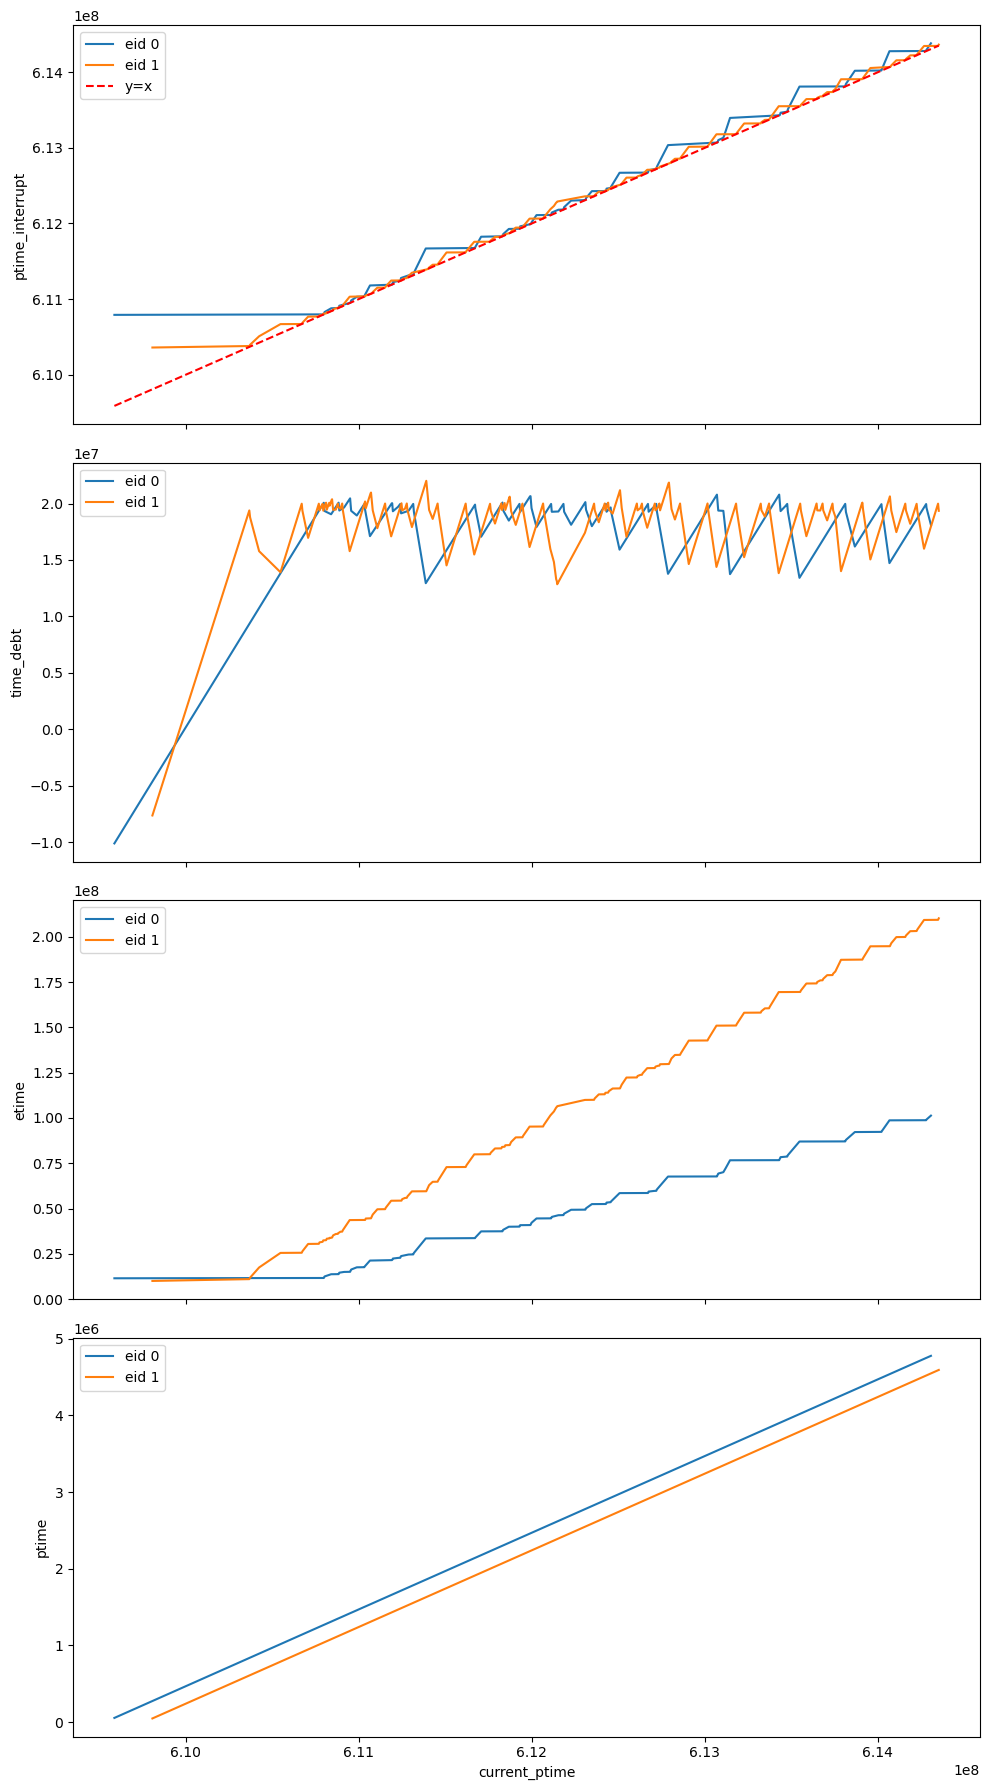

In [ ]:
# Qemu, Defend, Stress cpu 32, 2 processes
parse_and_plot_qemu_log('qemu1.txt')

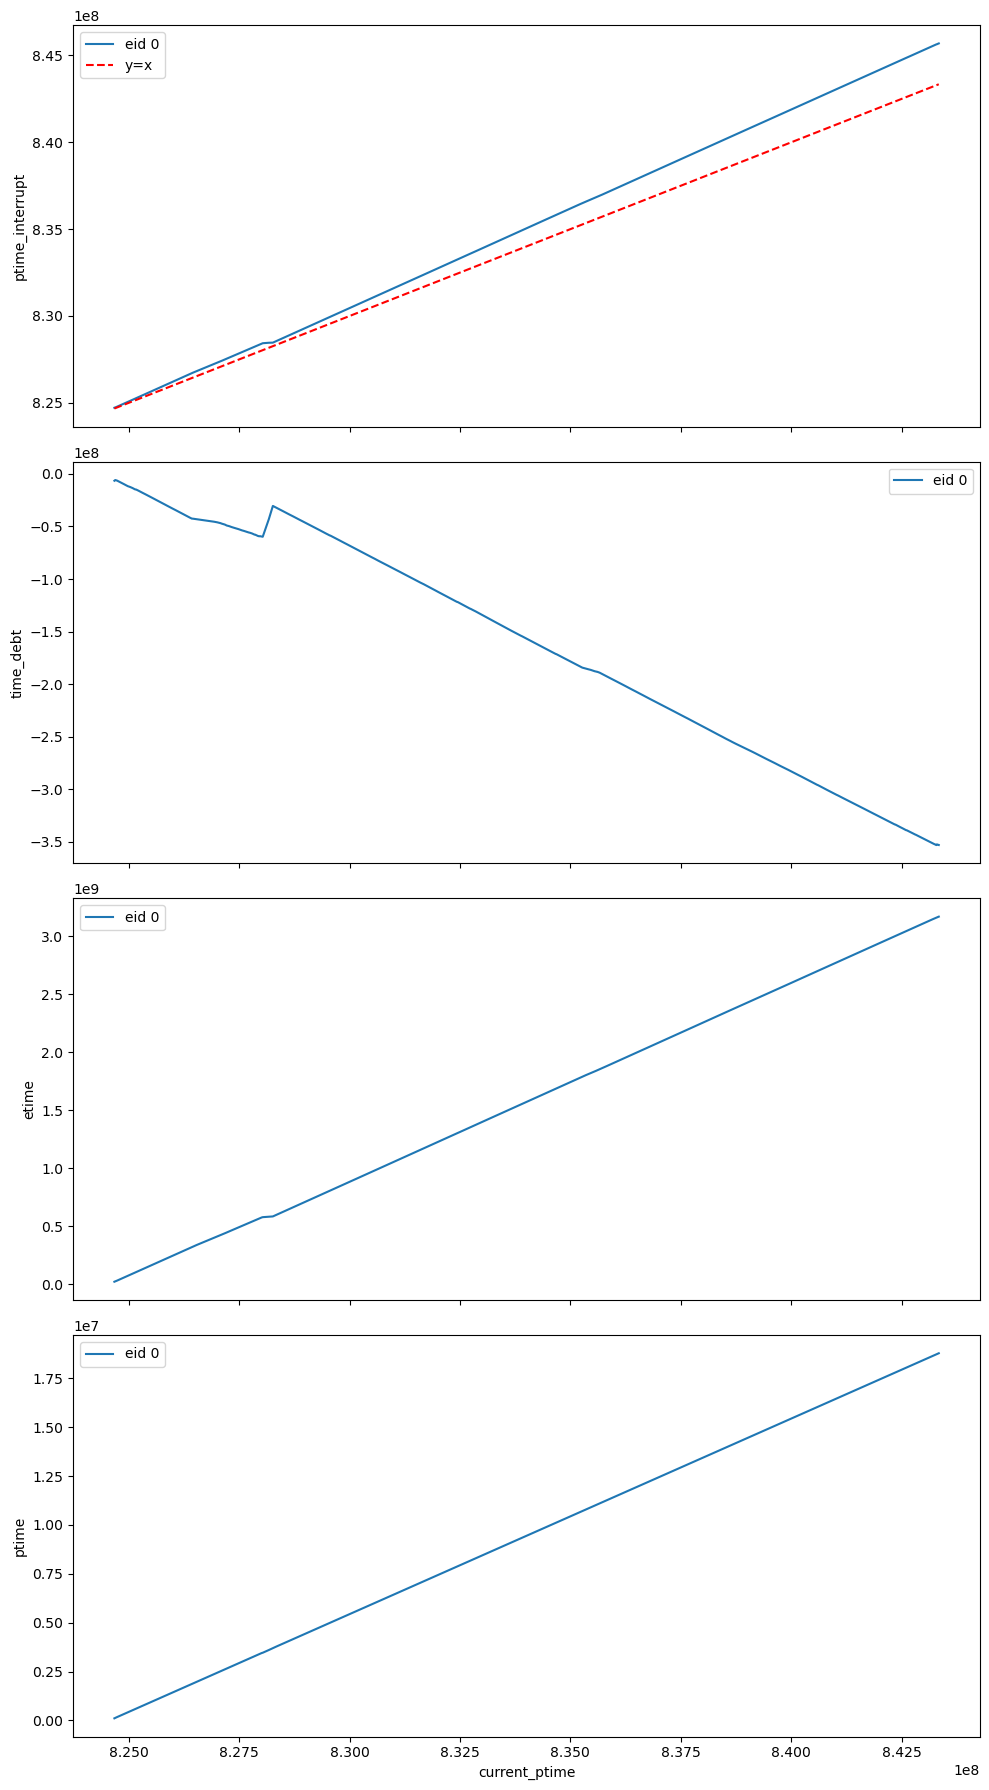

In [8]:
parse_and_plot_qemu_log('qemu_normal_defend_coremark.txt')

Coremark scores
* qemu
stress/defend   no-defend defend
nostress        4538      4581 
stress64       62        2984

/tmp/ipykernel_2377813/3246663125.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_eids))


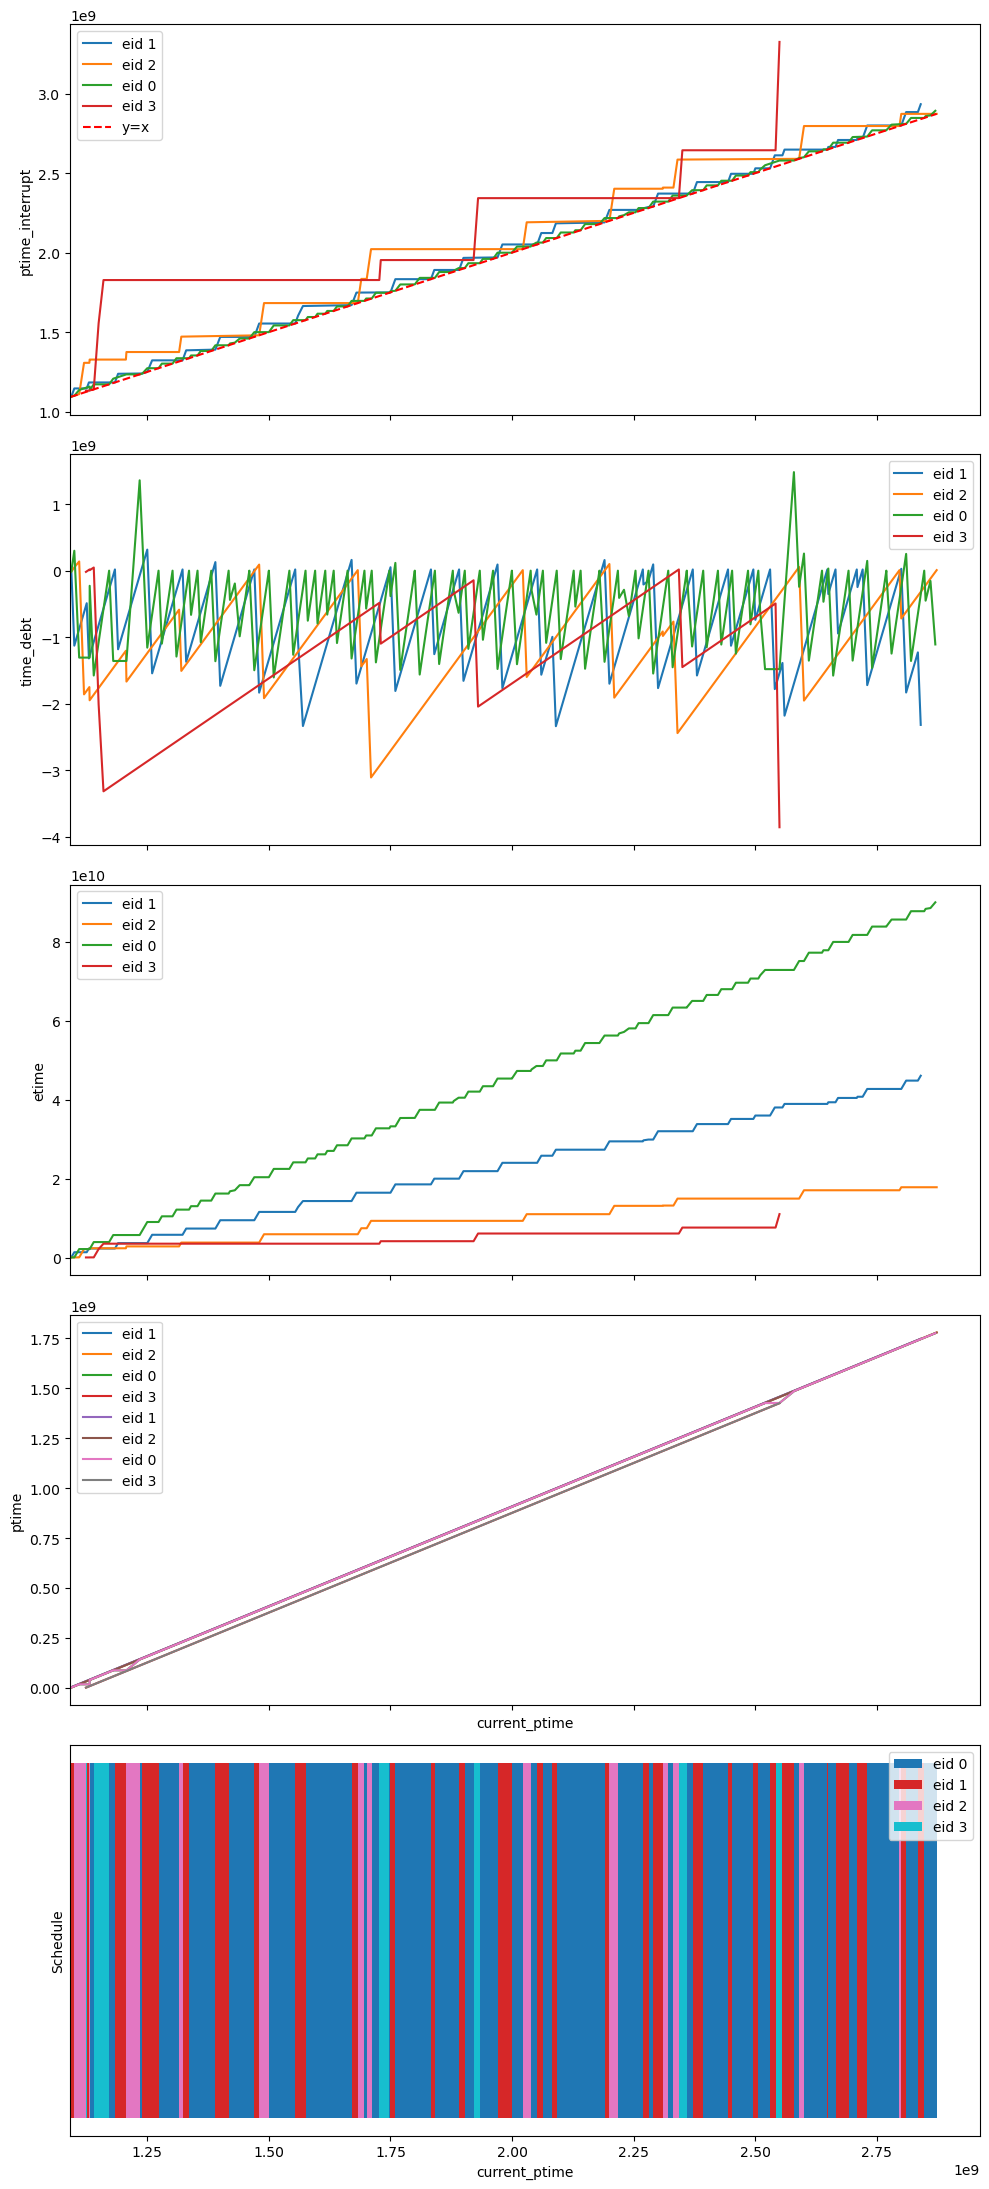

In [7]:
parse_and_plot_qemu_log('qemu_stress_defend_4process.txt')

Stopping plot for eid 1 at current_ptime 400023878 due to ptime > 4e8


/tmp/ipykernel_2377813/97837790.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_eids))


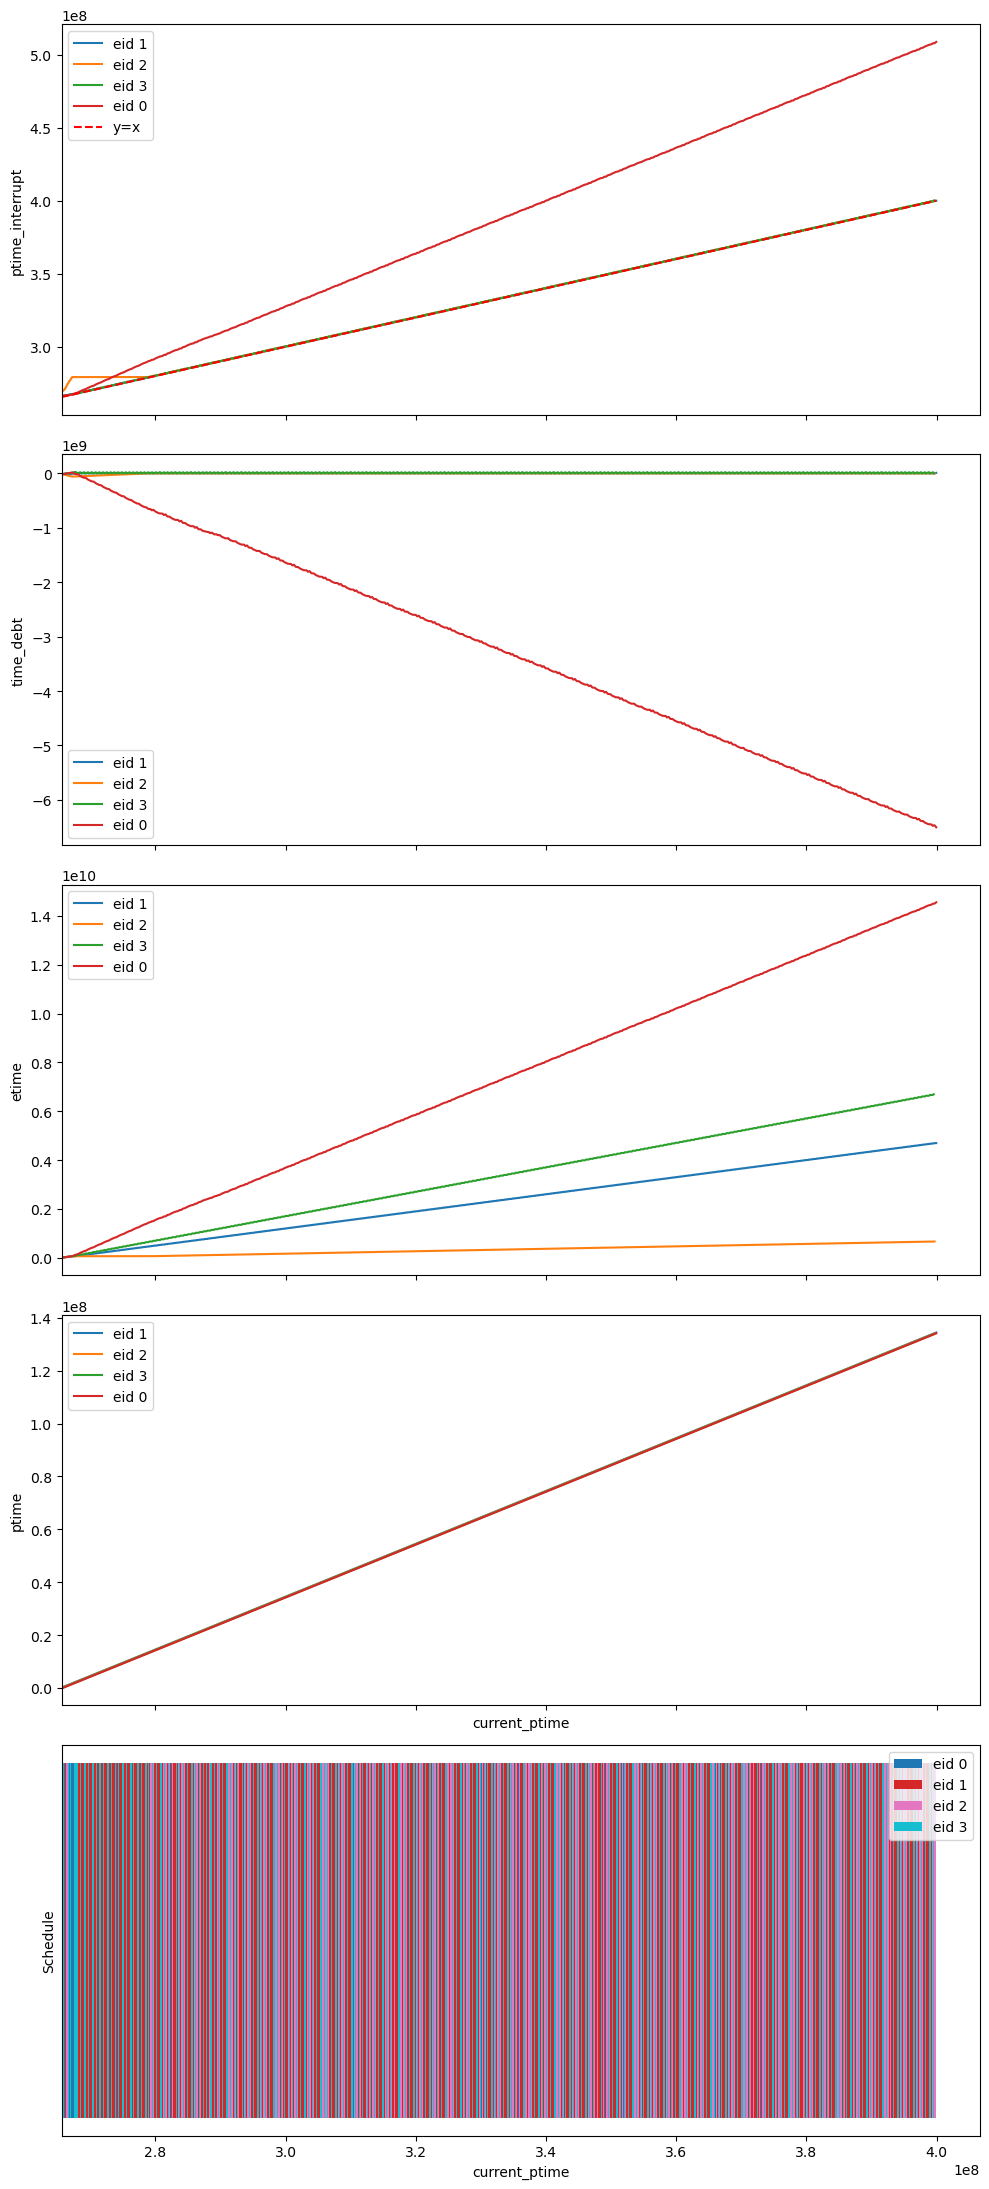

In [45]:
parse_and_plot_qemu_log('qemu_output.txt')